In [1]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## Import libraries

In [2]:
!git clone https://github.com/VuTrinhNguyenHoang/eX-LAViTs.git

Cloning into 'eX-LAViTs'...
remote: Enumerating objects: 472, done.
remote: Counting objects: 100% (121/121), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 472 (delta 73), reused 80 (delta 37), pack-reused 351 (from 1)
Receiving objects: 100% (472/472), 2.54 MiB | 20.13 MiB/s, done.
Resolving deltas: 100% (301/301), done.


In [3]:
%cd eX-LAViTs
!ls -l

/kaggle/working/eX-LAViTs
total 28
drwxr-xr-x 2 root root 4096 Feb 27 11:15 configs
drwxr-xr-x 2 root root 4096 Feb 27 11:15 datasets
drwxr-xr-x 2 root root 4096 Feb 27 11:15 notebooks
-rw-r--r-- 1 root root  315 Feb 27 11:15 README.md
-rw-r--r-- 1 root root   93 Feb 27 11:15 requirements.txt
drwxr-xr-x 4 root root 4096 Feb 27 11:15 src
drwxr-xr-x 2 root root 4096 Feb 27 11:15 tests


In [4]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="In 2.9, this function's implementation will be changed to use torchaudio.load_with_torchcodec*",
    category=UserWarning,
)

warnings.filterwarnings(
    "ignore",
    message="torio.io._streaming_media_decoder.StreamingMediaDecoder has been deprecated*",
    category=UserWarning,
)

In [5]:
# Repository
from src.models.linear_vit import create_linear_attention_vit
from src.models.explainability import ViTGradCAM, IntegratedGradient, Rollout, LAGRA
from src.utils.training import (
    create_run_directory, setup_logging, get_optimizer, get_scheduler,
    train_model, count_parameters, load_checkpoint
)
from src.pretrained import freeze_all_except_last_k_blocks, unfreeze_all
from src.utils.metrics import compute_loss_and_accuracy, compute_classification_metrics, evaluate_xai_method_dataset, evaluate_class_specificity_cosine
from src.utils.visualization import save_all_plots, create_training_summary_plot
from src.explain import visualize_methods
from src.utils.speech_preprocessing import Speech2Image, Speech2ImageConfig

# Pytorch
import torch
import torch.nn as nn
import torchaudio
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as T
from torchvision.transforms.autoaugment import AutoAugment, AutoAugmentPolicy
import timm
from sklearn.model_selection import train_test_split

from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np
import math
from tqdm.auto import tqdm
import os

## Config

In [6]:
run_name = "run001"

LR = 2e-4
WD = 1e-3

EPOCHS = 50
warmup_epochs = 10
remaining_epochs = EPOCHS - warmup_epochs

PATIENCE = 5

BATCH_SIZE = 64
NUM_WORKERS = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 224

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
print(NUM_WORKERS, DEVICE)

4 cpu


## Datasets

In [7]:
data_dir = Path("/kaggle/input/datasets/trnhvu/esc-50/ESC-50-master")
csv_path = data_dir / "meta" / "esc50.csv"
audio_dir = data_dir / "audio"

esc_df = pd.read_csv(csv_path)
esc_df.head()

,filename,fold,target,category,esc10,src_file,take
0,1-100032-A-0.wav,1,0,dog,True,100032,A
1,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A
2,1-100210-A-36.wav,1,36,vacuum_cleaner,False,100210,A
3,1-100210-B-36.wav,1,36,vacuum_cleaner,False,100210,B
4,1-101296-A-19.wav,1,19,thunderstorm,False,101296,A


In [8]:
esc_df["path"] = esc_df["filename"].apply(lambda x: str(audio_dir / x))
esc_df["label_idx"] = esc_df["target"].astype(int)

idx2label = dict(esc_df.drop_duplicates("label_idx")[["label_idx","category"]].values)
label2idx = {v:k for k,v in idx2label.items()}

CLASSES = [idx2label[i] for i in range(len(idx2label))]
NUM_CLASSES = len(CLASSES)
print("NUM_CLASSES:", NUM_CLASSES)

NUM_CLASSES: 50


In [9]:
TEST_FOLD = 1

test_df = esc_df[esc_df["fold"] == TEST_FOLD].copy().reset_index(drop=True)
trainval_df = esc_df[esc_df["fold"] != TEST_FOLD].copy().reset_index(drop=True)

# valid tách từ trainval (ESC-50 cân bằng, stratify theo label_idx)
VALID_RATIO = 0.1
train_df, valid_df = train_test_split(
    trainval_df,
    test_size=VALID_RATIO,
    random_state=SEED,
    stratify=trainval_df["label_idx"],
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("Train:", len(train_df), "Valid:", len(valid_df), "Test:", len(test_df))
train_df.head()

Train: 1440 Valid: 160 Test: 400


,filename,fold,target,category,esc10,src_file,take,path,label_idx
0,3-70962-B-4.wav,3,4,frog,False,70962,B,/kaggle/input/datasets/trnhvu/esc-50/ESC-50-ma...,4
1,2-77945-B-41.wav,2,41,chainsaw,True,77945,B,/kaggle/input/datasets/trnhvu/esc-50/ESC-50-ma...,41
2,2-109371-A-16.wav,2,16,wind,False,109371,A,/kaggle/input/datasets/trnhvu/esc-50/ESC-50-ma...,16
3,2-104877-A-3.wav,2,3,cow,False,104877,A,/kaggle/input/datasets/trnhvu/esc-50/ESC-50-ma...,3
4,3-118972-B-41.wav,3,41,chainsaw,True,118972,B,/kaggle/input/datasets/trnhvu/esc-50/ESC-50-ma...,41


### Create Dataset

In [10]:
IMAGENET_NORM = T.Normalize(
    mean=(0.485, 0.456, 0.406),
    std=(0.229, 0.224, 0.225),
)

class ESC50Dataset(Dataset):
    def __init__(self, df, s2i_cfg=None, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

        self.s2i = Speech2Image(
            s2i_cfg or Speech2ImageConfig(
                sample_rate=16000,
                window_sec=5.0,      # ESC-50 ~ 5 seconds
                n_fft=512,
                win_length=400,
                hop_length=160,
                n_mels=224,
                fmin=20.0,
                fmax=7600.0,
                out_hw=224
            )
        )

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav, sr = torchaudio.load(row["path"])  # [C, T]

        # mono
        if wav.size(0) > 1:
            wav = wav.mean(dim=0)
        else:
            wav = wav.squeeze(0)

        # resample -> 16k
        if sr != 16000:
            wav = torchaudio.functional.resample(wav, sr, 16000)

        x = self.s2i(wav)                       # [3,224,224]
        if self.transform is not None:
            x = self.transform(x)
            
        y = torch.tensor(int(row["label_idx"])).long()
        return x, y

In [11]:
train_ds = ESC50Dataset(train_df, transform=IMAGENET_NORM)
valid_ds = ESC50Dataset(valid_df, transform=IMAGENET_NORM)
test_ds = ESC50Dataset(test_df, transform=IMAGENET_NORM)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, 
                          num_workers=NUM_WORKERS, pin_memory=True, persistent_workers=True)

len(train_loader), len(valid_loader), len(test_loader)

/usr/local/lib/python3.12/dist-packages/torchaudio/functional/functional.py:582: UserWarning: At least one mel filterbank has all zero values. The value for `n_mels` (224) may be set too high. Or, the value for `n_freqs` (257) may be set too low.
  warnings.warn(


(23, 3, 7)

In [12]:
batch_test = next(iter(train_loader))
batch_test[0].shape, batch_test[1].shape

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


(torch.Size([64, 3, 224, 224]), torch.Size([64]))

## Train model

In [13]:
model_name = "vit_tiny_patch16_224"

model = create_linear_attention_vit(
    model_name,
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_path_rate=0.1,
    attn_drop_rate=0.1,
    proj_drop_rate=0.1,
)

Creating Linear Attention ViT: vit_tiny_patch16_224
    Pretrained: True
    Classes: 50
    Image size: 224


model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

    Original parameters: 5,534,066
Replacing attention layers with LinearMultiheadAttention...
    Kernel: elu
    Epsilon: 1e-06
   Block 0: dim=192, heads=3, mlp_ratio=4.0
   Block 1: dim=192, heads=3, mlp_ratio=4.0
   Block 2: dim=192, heads=3, mlp_ratio=4.0
   Block 3: dim=192, heads=3, mlp_ratio=4.0
   Block 4: dim=192, heads=3, mlp_ratio=4.0
   Block 5: dim=192, heads=3, mlp_ratio=4.0
   Block 6: dim=192, heads=3, mlp_ratio=4.0
   Block 7: dim=192, heads=3, mlp_ratio=4.0
   Block 8: dim=192, heads=3, mlp_ratio=4.0
   Block 9: dim=192, heads=3, mlp_ratio=4.0
   Block 10: dim=192, heads=3, mlp_ratio=4.0
   Block 11: dim=192, heads=3, mlp_ratio=4.0
Successfully replaced 12 attention blocks
    Total parameters: 5,534,066
    Trainable parameters: 5,534,066


In [14]:
run_dir = create_run_directory("experiments", run_name)
print(f"Created run directory: {run_dir}")

logger = setup_logging(os.path.join(run_dir, 'logs'))
logger.info(f"Starting training with {run_name}")
logger.info(f"Using device: {DEVICE}")

logger.info(f"Train batches: {len(train_loader)}")
logger.info(f"Validation batches: {len(valid_loader)}")
logger.info(f"Test batches: {len(test_loader)}")

model = model.to(DEVICE)
total_params, trainable_params = count_parameters(model)
logger.info(f"Model loaded with {total_params:,} total parameters ({trainable_params:,} trainable)")

criterion = nn.CrossEntropyLoss()
logger.info("Starting training...")

2026-02-27 11:16:10 - training - INFO - Starting training with run001
2026-02-27 11:16:10 - training - INFO - Using device: cpu
2026-02-27 11:16:10 - training - INFO - Train batches: 23
2026-02-27 11:16:10 - training - INFO - Validation batches: 3
2026-02-27 11:16:10 - training - INFO - Test batches: 7
2026-02-27 11:16:10 - training - INFO - Model loaded with 5,534,066 total parameters (5,534,066 trainable)
2026-02-27 11:16:10 - training - INFO - Starting training...


Created run directory: experiments/run001


In [15]:
if warmup_epochs > 0:
    logger.info(f"Phase 1: Warm-up last 6 blocks for {warmup_epochs} epochs")
    freeze_all_except_last_k_blocks(model, k=6, logger=logger)
    optimizer1 = get_optimizer(
        model,
        optimizer_name="adamw",
        learning_rate=LR * 0.5,
        weight_decay=WD,
    )
    scheduler1 = get_scheduler(
        optimizer1, 
        "cosine", 
        **{
            "T_max": warmup_epochs,
            "eta_min": 0
        }
    )

    metrics_phase1 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer1,
        scheduler=scheduler1,
        device=DEVICE,
        num_epochs=warmup_epochs,
        run_dir=run_dir,
        save_freq=50,
        print_freq=50,
        early_stopping_patience=PATIENCE,
        logger=logger
    )
    logger.info("Phase 1 completed.")

2026-02-27 11:16:10 - training - INFO - Phase 1: Warm-up last 6 blocks for 10 epochs
2026-02-27 11:16:10 - training - INFO - [Warmup] Trainable params with last 6 blocks: 3,568,562
2026-02-27 11:16:10 - training - INFO - Starting epoch 1/10
2026-02-27 11:16:30 - training - INFO - Epoch: [1][0/23]	Time 19.202 (19.202)	Loss 4.7241 (4.7241)	Acc@1 4.688 (4.688)	Memory 3246MB
2026-02-27 11:19:41 - training - INFO - Validation: [1]	Time 2.903 (Total: 8.71s)	Loss 3.6686	Acc@1 6.250	Memory 6858MB
2026-02-27 11:19:41 - training - INFO - New best model saved with validation accuracy: 6.250
2026-02-27 11:19:41 - training - INFO - Epoch 1 completed. Train Loss: 4.0599, Val Loss: 3.6686, Val Acc: 6.25%, Epoch Time: 210.19s, Memory: 6839MB
2026-02-27 11:19:41 - training - INFO - Starting epoch 2/10
2026-02-27 11:19:59 - training - INFO - Epoch: [2][0/23]	Time 18.563 (18.563)	Loss 3.6391 (3.6391)	Acc@1 7.812 (7.812)	Memory 6876MB
2026-02-27 11:23:05 - training - INFO - Validation: [2]	Time 2.190 (Tot

In [16]:
if remaining_epochs > 0:
    logger.info(f"Phase 2: Unfreeze last 12 blocks and finetune for {remaining_epochs} epochs")
    freeze_all_except_last_k_blocks(model, k=12, logger=logger)
    optimizer2 = get_optimizer(
        model,
        optimizer_name="adamw",
        learning_rate=LR,
        weight_decay=WD,
    )
    scheduler2 = get_scheduler(
        optimizer2, 
        "cosine", 
        **{
            "T_max": remaining_epochs,
            "eta_min": 0
        }
    )

    metrics_phase2 = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=valid_loader,
        criterion=criterion,
        optimizer=optimizer2,
        scheduler=scheduler2,
        device=DEVICE,
        num_epochs=remaining_epochs,
        run_dir=run_dir,
        save_freq=50,
        print_freq=50,
        early_stopping_patience=PATIENCE,
        logger=logger
    )
    logger.info("Phase 2 completed.")

2026-02-27 11:49:14 - training - INFO - Phase 2: Unfreeze last 12 blocks and finetune for 40 epochs
2026-02-27 11:49:14 - training - INFO - [Warmup] Trainable params with last 12 blocks: 5,348,402
2026-02-27 11:49:14 - training - INFO - Starting epoch 1/40
2026-02-27 11:49:28 - training - INFO - Epoch: [1][0/23]	Time 13.476 (13.476)	Loss 2.5485 (2.5485)	Acc@1 29.688 (29.688)	Memory 6877MB
2026-02-27 11:52:42 - training - INFO - Validation: [1]	Time 2.168 (Total: 6.51s)	Loss 2.7036	Acc@1 23.125	Memory 6858MB
2026-02-27 11:52:42 - training - INFO - New best model saved with validation accuracy: 23.125
2026-02-27 11:52:42 - training - INFO - Epoch 1 completed. Train Loss: 2.9657, Val Loss: 2.7036, Val Acc: 23.12%, Epoch Time: 208.05s, Memory: 6840MB
2026-02-27 11:52:42 - training - INFO - Starting epoch 2/40
2026-02-27 11:52:56 - training - INFO - Epoch: [2][0/23]	Time 13.679 (13.679)	Loss 2.4931 (2.4931)	Acc@1 28.125 (28.125)	Memory 6877MB
2026-02-27 11:56:11 - training - INFO - Validati

## Evaluate

In [17]:
logger.info("Training completed!")

# Evaluate on test setlogger.info("Evaluating on test set...")
test_results = compute_loss_and_accuracy(
    model, test_loader, criterion, DEVICE, return_predictions=True
)

# Compute detailed classification metrics
classification_metrics = compute_classification_metrics(
    test_results['predictions'],
    test_results['targets'],
    return_confusion_matrix=True
)

# Log test results
logger.info(f"Test Results:")
logger.info(f"  Loss: {test_results['loss']:.4f}")
logger.info(f"  Top-1 Accuracy: {test_results['top1_accuracy']:.2f}%")
logger.info(f"  Macro F1-Score: {classification_metrics['macro_f1']:.2f}%")
logger.info(f"  Weighted F1-Score: {classification_metrics['weighted_f1']:.2f}%")

2026-02-27 13:16:18 - training - INFO - Training completed!
2026-02-27 13:16:36 - training - INFO - Test Results:
2026-02-27 13:16:36 - training - INFO -   Loss: 1.8386
2026-02-27 13:16:36 - training - INFO -   Top-1 Accuracy: 59.75%
2026-02-27 13:16:36 - training - INFO -   Macro F1-Score: 58.41%
2026-02-27 13:16:36 - training - INFO -   Weighted F1-Score: 58.41%


2026-02-27 13:16:37 - training - INFO - Generating plots...


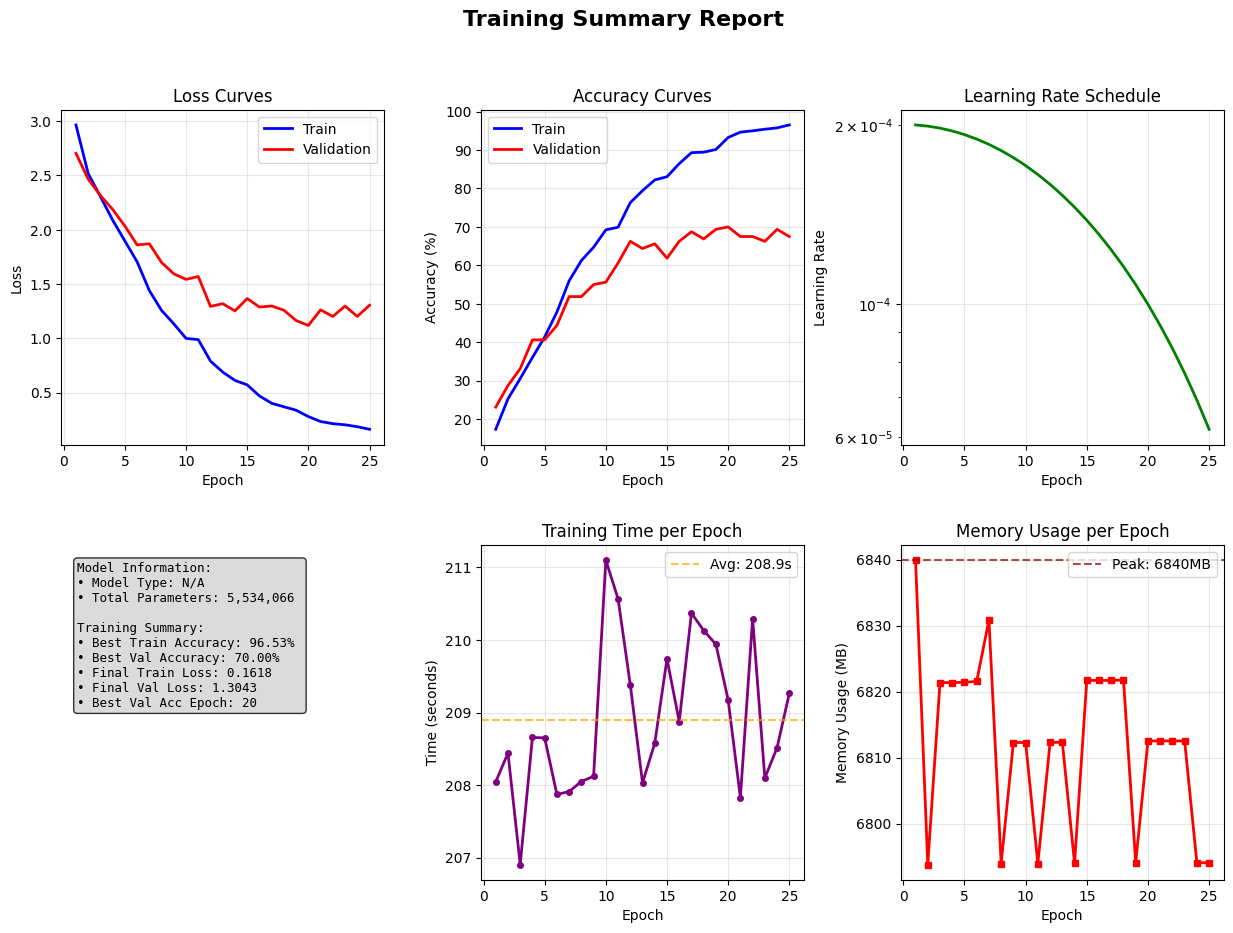

In [18]:
# Generate and save plots
logger.info("Generating plots...")
save_all_plots(
    metrics_tracker=metrics_phase2,
    run_dir=run_dir,
    y_true=test_results['targets'],
    y_pred=test_results['predictions'],
)

# Create comprehensive training summary plot
model_info = {
    'model_name': model_name,
    'total_params': total_params,
}

summary_plot = create_training_summary_plot(metrics_phase2, model_info)
summary_plot.savefig(
    os.path.join(run_dir, 'plots', 'training_summary.png'),
    bbox_inches='tight', dpi=300
)

## Explain

In [19]:
# model_name = "vit_tiny_patch16_224"
# checkpoint_path = ""

# model = create_linear_attention_vit(
#     model_name,
#     pretrained=False,
#     num_classes=len(CLASSES)
# )

# load_checkpoint(
#     checkpoint_path,
#     model,
#     device=DEVICE
# )

model.to(DEVICE).eval()

VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 192, kernel_size=(16, 16), stride=(16, 16))
    (norm): Identity()
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (patch_drop): Identity()
  (norm_pre): Identity()
  (blocks): Sequential(
    (0): LinearAttentionBlock(
      (norm1): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (attn): LinearMultiheadAttention(
        (qkv): Linear(in_features=192, out_features=576, bias=True)
        (out_proj): Linear(in_features=192, out_features=192, bias=True)
        (proj_drop): Dropout(p=0.1, inplace=False)
        (attn_drop): Dropout(p=0.1, inplace=False)
      )
      (drop_path1): Identity()
      (norm2): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=192, out_features=768, bias=True)
        (act): GELU(approximate='none')
        (drop1): Dropout(p=0.1, inplace=False)
        (fc2): Linear(in_features=768, out_features=192, bias=True)
       

In [20]:
%matplotlib inline
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats('retina')

### LAGRA

In [21]:
idx = np.random.randint(len(test_ds))

x, y_true = test_ds[idx] # test sample
xb = x.unsqueeze(0).to(DEVICE)

In [22]:
proposal_model = LAGRA(model, has_cls=True, blocks_attr="blocks")

out = proposal_model.attribute(xb, use_logits=True)

In [23]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.2451, grad_fn=<MeanBackward0>),
 tensor(0.2208, grad_fn=<MeanBackward0>))

### GradCAM

In [24]:
gradcam_model = ViTGradCAM(model, has_cls=True)

out = gradcam_model.attribute(xb)

In [25]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.7232, grad_fn=<MeanBackward0>),
 tensor(0.6678, grad_fn=<MeanBackward0>))

### Integrated Gradients

In [26]:
ig_model = IntegratedGradient(model, m_steps=32)

out = ig_model.attribute(xb)

In [27]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.1943),
 tensor(0.0333))

### Rollout

In [28]:
rollout_model = Rollout(model, has_cls=True)

out = rollout_model.attribute(xb)

In [29]:
out[0].shape, out[1].shape, out[0].mean(), out[1].mean()

(torch.Size([1, 196]),
 torch.Size([1, 1, 224, 224]),
 tensor(0.6249),
 tensor(0.5341))

## Visualization

348


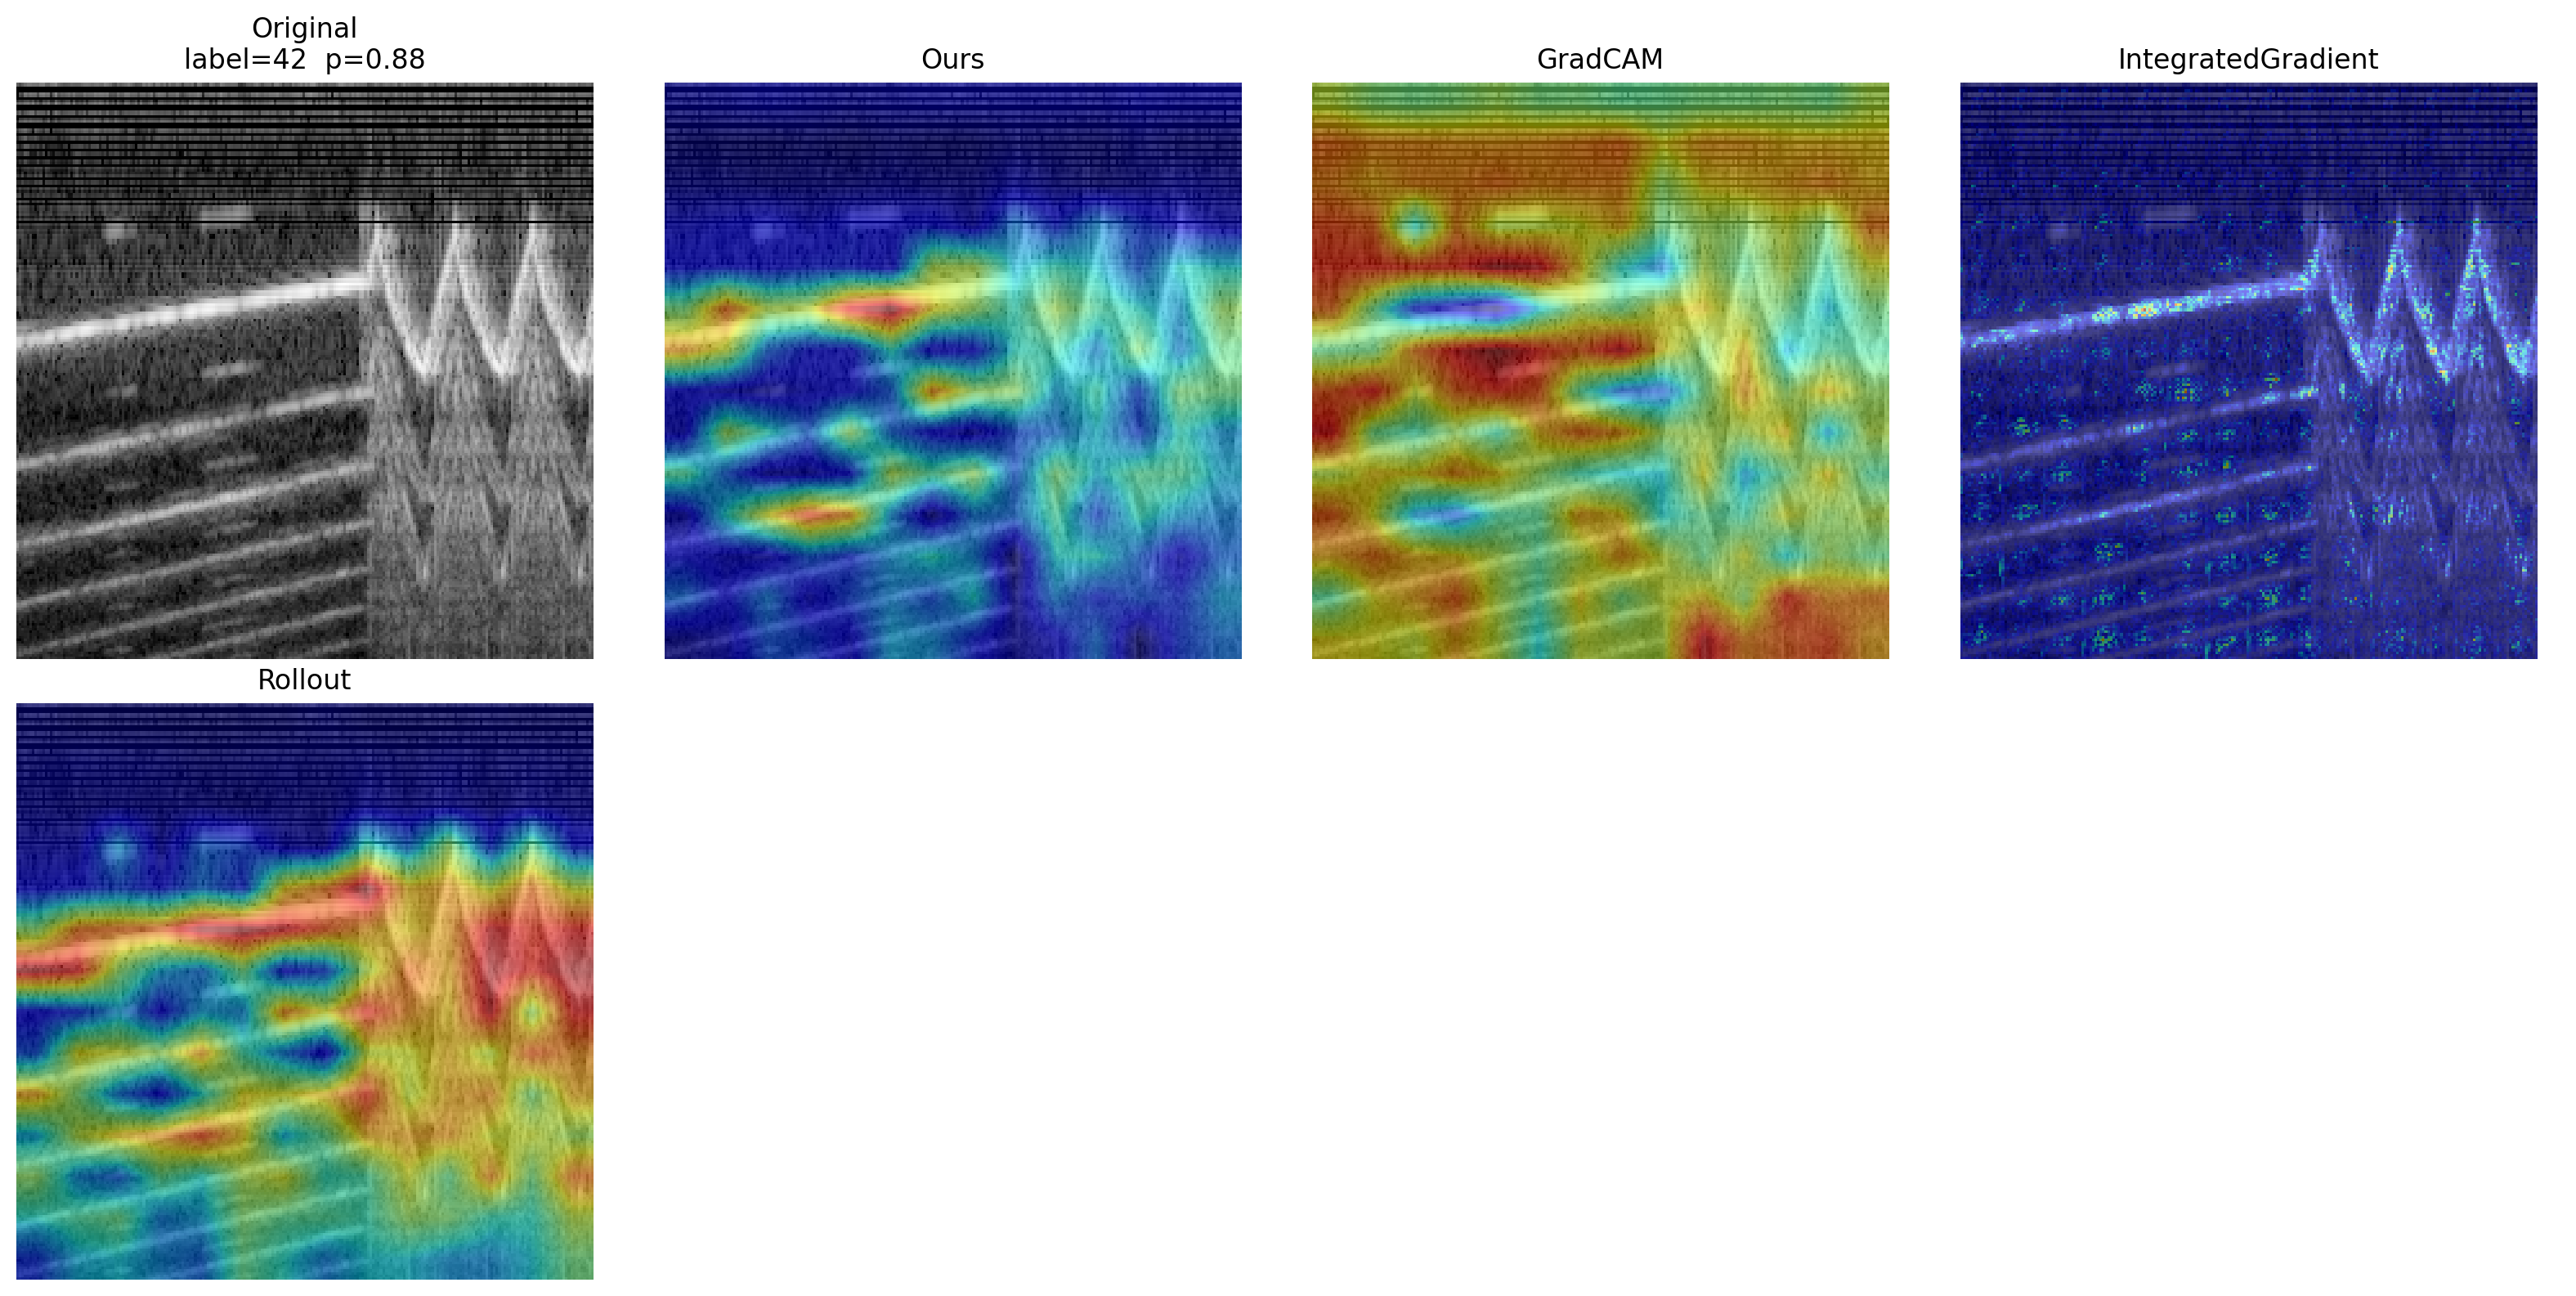

In [30]:
idx = np.random.randint(len(test_ds))
print(idx)

_ = visualize_methods(
    test_ds, idx,
    {
        "Ours": proposal_model,
        "GradCAM": gradcam_model,
        "IntegratedGradient": ig_model,
        "Rollout": rollout_model
    },
    use_pred=True,
    device=DEVICE,
)

## Evaluate Explain methods

In [31]:
methods = {
    "Ours": proposal_model,
    "GradCAM": gradcam_model,
    "IG": ig_model,
    "Rollout": rollout_model
}

results = {}
for name, attr in methods.items():
    print(f"Evaluating {name}...")
    stats_faith = evaluate_xai_method_dataset(
        attributor=attr,
        dataset=test_ds,
        device=DEVICE,
        use_pred=True,
        max_samples=None,
        steps=20,
        baseline=None,
        use_logits=True,
        verbose_every=50,
    )

    stats_cs = evaluate_class_specificity_cosine(
        attributor=attr,
        dataset=test_ds,
        device=DEVICE,
        max_samples=None,
        use_logits=True,
        use_pred=True,
        verbose_every=50,
    )

    metrics = {
        **stats_faith,
        "cosine_cs_mean": stats_cs["cosine_cs_mean"],
        "cosine_cs_std": stats_cs["cosine_cs_std"],
    }
    results[name] = metrics
    print(f"Results for {name}: {metrics}")
    print("-" * 50)

Evaluating Ours...
[50/400] AUC_del_mean=0.2698, AUC_ins_mean=0.4371, entropy_mean=0.9552
[100/400] AUC_del_mean=0.2880, AUC_ins_mean=0.4591, entropy_mean=0.9564
[150/400] AUC_del_mean=0.2772, AUC_ins_mean=0.4357, entropy_mean=0.9540
[200/400] AUC_del_mean=0.2623, AUC_ins_mean=0.4264, entropy_mean=0.9543
[250/400] AUC_del_mean=0.2717, AUC_ins_mean=0.4297, entropy_mean=0.9558
[300/400] AUC_del_mean=0.2737, AUC_ins_mean=0.4290, entropy_mean=0.9563
[350/400] AUC_del_mean=0.2734, AUC_ins_mean=0.4311, entropy_mean=0.9555
[400/400] AUC_del_mean=0.2779, AUC_ins_mean=0.4374, entropy_mean=0.9558
[50/400] cosine_cs_mean=0.2546
[100/400] cosine_cs_mean=0.2028
[150/400] cosine_cs_mean=0.2055
[200/400] cosine_cs_mean=0.2273
[250/400] cosine_cs_mean=0.1912
[300/400] cosine_cs_mean=0.1946
[350/400] cosine_cs_mean=0.1938
[400/400] cosine_cs_mean=0.2070
Results for Ours: {'auc_del_mean': 0.2778962279668245, 'auc_ins_mean': 0.43735177998127356, 'entropy_mean': 0.9558301950048395, 'gini_mean': 0.99193735

In [32]:
results

{'Ours': {'auc_del_mean': 0.2778962279668245,
  'auc_ins_mean': 0.43735177998127356,
  'entropy_mean': 0.9558301950048395,
  'gini_mean': 0.9919373596773948,
  'n_samples': 400,
  'cosine_cs_mean': 0.2070039095183347,
  'cosine_cs_std': 0.38616797485106913},
 'GradCAM': {'auc_del_mean': 0.3297685987539512,
  'auc_ins_mean': 0.3996333304741508,
  'entropy_mean': 0.9944530444164301,
  'gini_mean': 0.9946170617442113,
  'n_samples': 400,
  'cosine_cs_mean': 0.43028266510431423,
  'cosine_cs_std': 0.35757635391441456},
 'IG': {'auc_del_mean': 0.29013436014119476,
  'auc_ins_mean': 0.426179669127753,
  'entropy_mean': 0.9716709912948127,
  'gini_mean': 0.9932051072712056,
  'n_samples': 400,
  'cosine_cs_mean': 0.6428358393907547,
  'cosine_cs_std': 0.08290206653751286},
 'Rollout': {'auc_del_mean': 0.27819396290514525,
  'auc_ins_mean': 0.42365466903097626,
  'entropy_mean': 0.9853320555890807,
  'gini_mean': 0.994085525291739,
  'n_samples': 400,
  'cosine_cs_mean': 1.0000002205371856,
  